In [2]:
# Import necessary libraries
import os
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
import netCDF4 as nc

In [3]:
# Function to open an npz file
def open_npz_file(npz_path):
    """Open an npz file and return the chip and metadata"""
    try:
        archive = np.load(npz_path, allow_pickle=True)
        chip = archive['chip']
        data = archive['data'].item()
        return chip, data
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None, None

In [4]:
# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

In [5]:
# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])
abiLong[abiLong < 0] += 360

In [6]:
def visualize_chips(lon_chip, lat_chip, abi_image, data):
    # 1. Create the 'canvas'
    plt.figure(figsize=(10, 8))
    # 2. Define the geographic boundaries of the chip
    # extent = [left, right, bottom, top]
    img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
    # 3. Draw the ABI image
    # cmap='gray' makes it look like a standard satellite image
    # origin='upper' ensures the top of the array is the top of the plot
    # plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
    plt.imshow(abi_image, extent=img_extent, cmap='gray') 
    # plt.imshow(abi_image) 
    # 4. Add a colorbar so you know what the values mean
    plt.colorbar(label='Radiance')
    # 5. Draw the transect on top!
    # data['Longitude'] and data['Latitude'] are your 91 points
    # plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
    plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
    # 6. Add labels and a title
    plt.title("ABI Chip with CloudSat Transect Overlay")
    plt.xlabel("Longitude")
    plt.ylabel("Latitude")
    plt.legend()
    # 7. Show the plot
    plt.show()

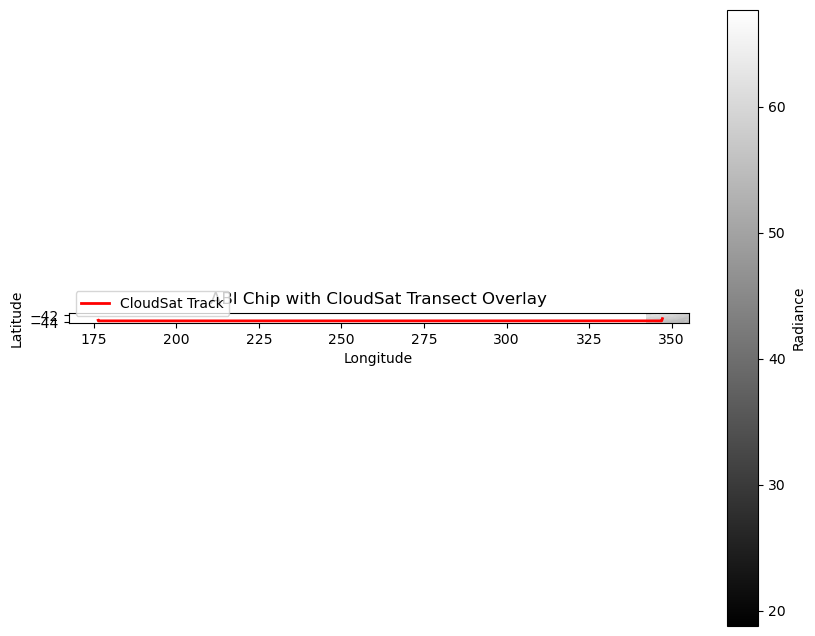

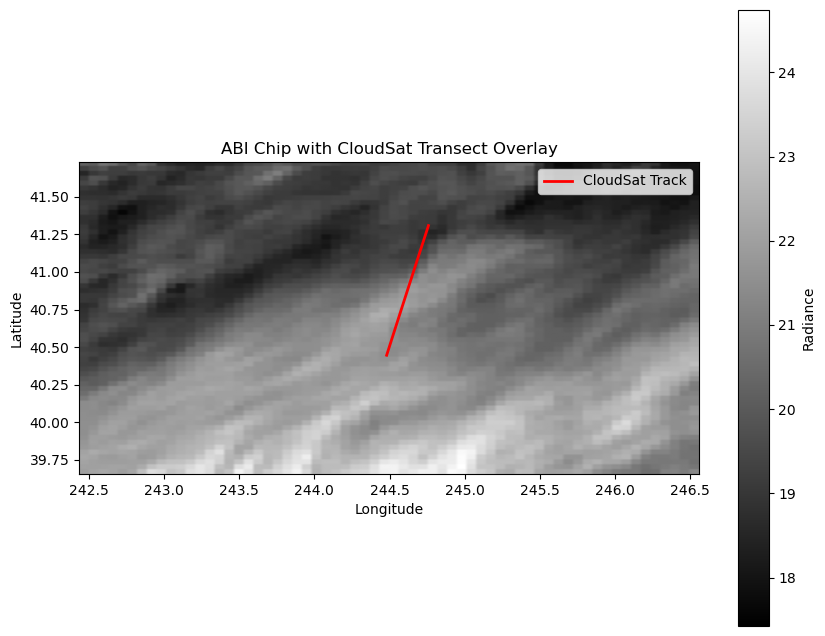

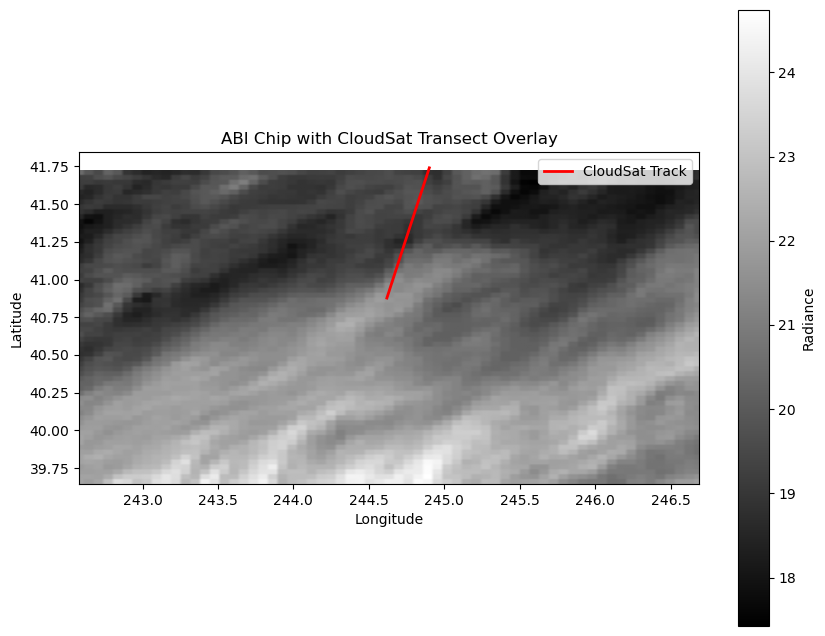

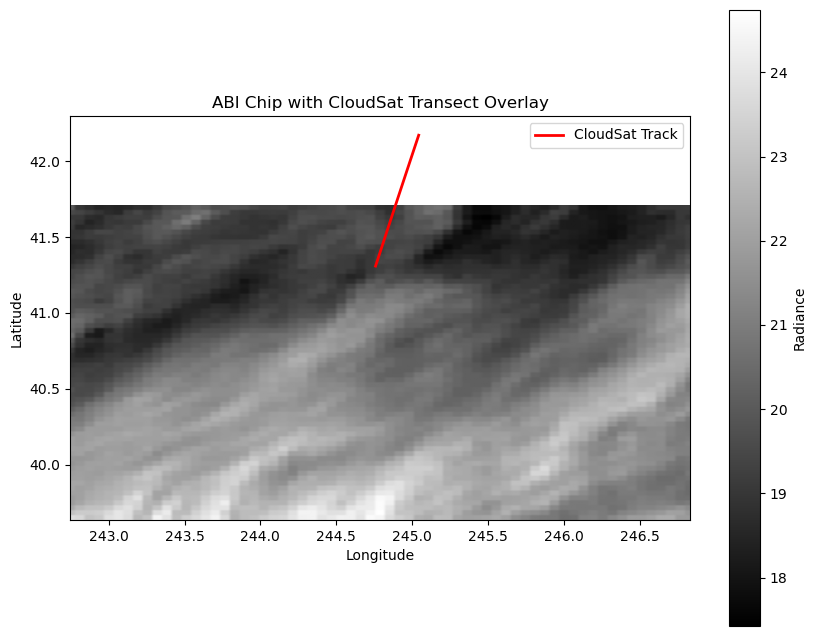

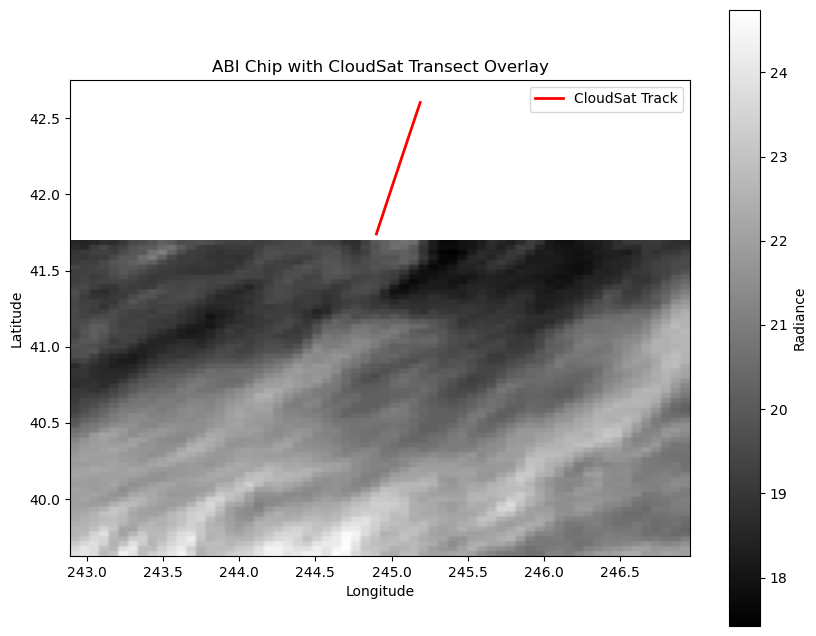

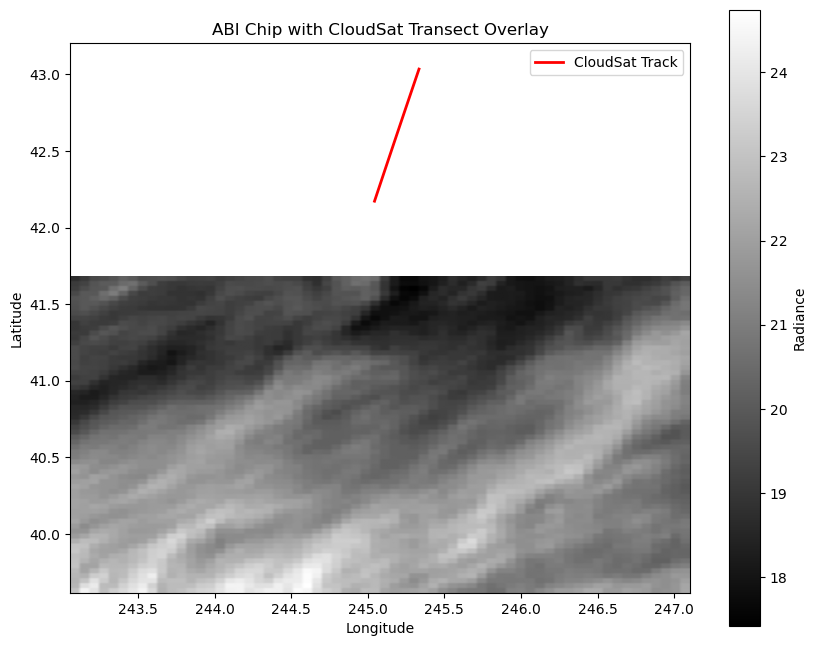

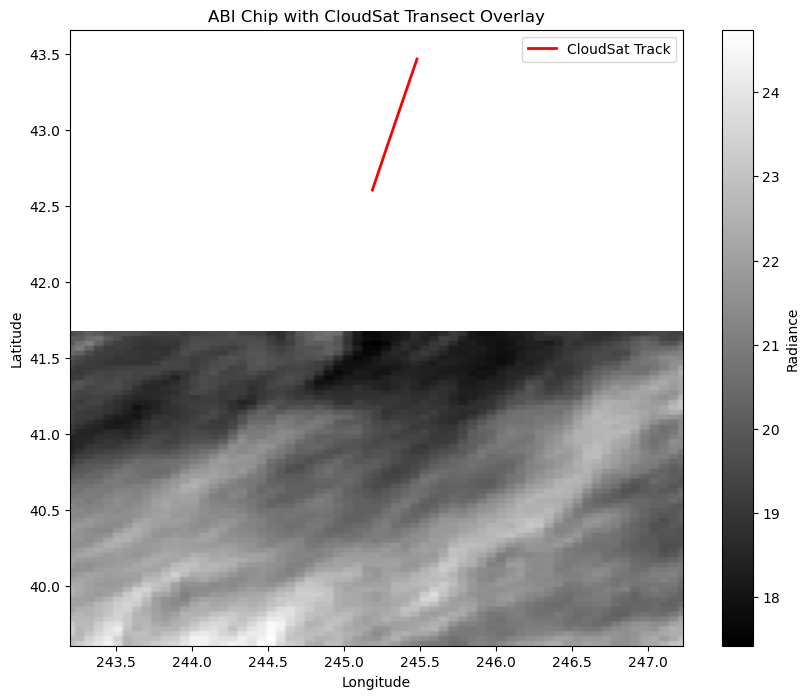

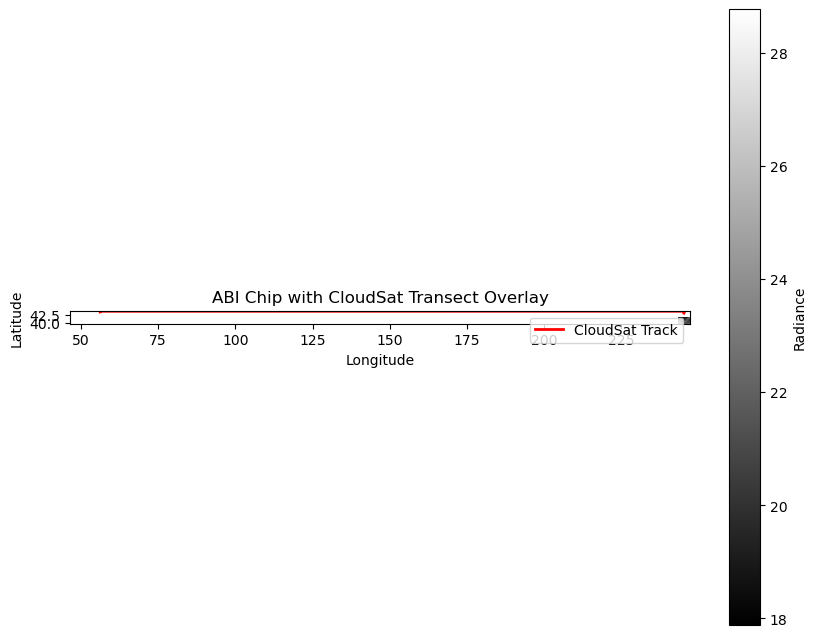

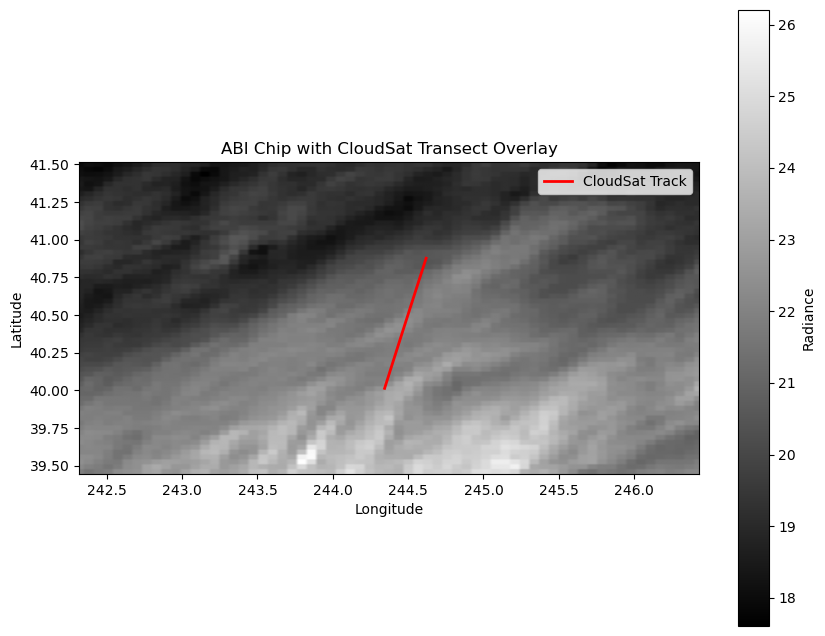

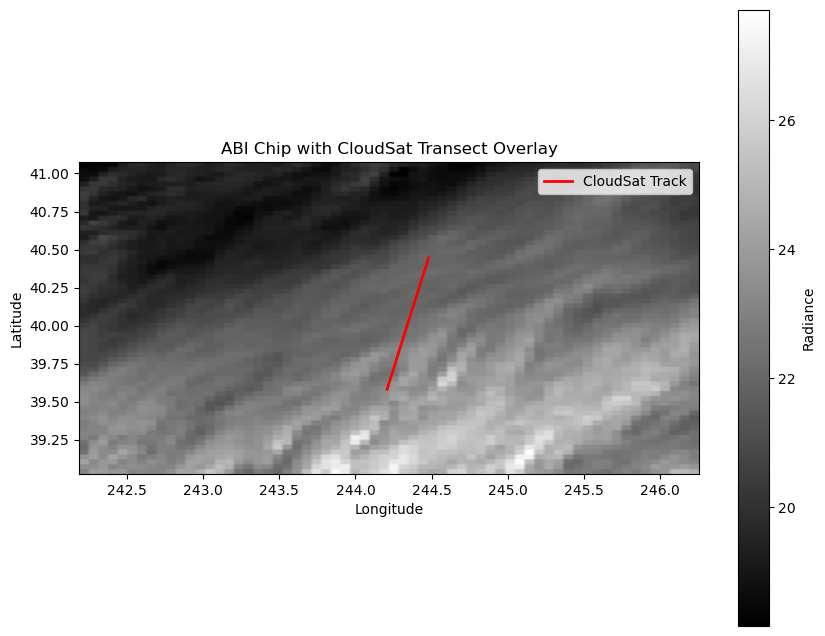

10


In [ ]:
output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/'
files = find_npz_files(output_directory)

half = 64

count =0

for file in files:
    chip, data = open_npz_file(file)
    coords = file.split('/')[-1].split('_')[-1].split('-')
    # print(file.split('/')[-1].split('_')[-1].split('-'))
    y_center = int(coords[0])
    x_center = int(coords[1])
    
    
    lat_chip = abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
    lon_chip = abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
    
    abi_image = chip[2, :, :, 12]
    
    if data["Longitude"][0] < 250 and data["Longitude"][0] > 150:
        count +=1
    
        # print(y_center, x_center)
        visualize_chips(lon_chip, lat_chip, abi_image, data)
        
    if count == 10:
        break

print(count)

# this is very messed up
   
    


In [ ]:

output_directory = '/home/al8425b-hpc/NASA/satvision-pix4d/examples/abi_3d_reconstruction/originalChipTest/output/2020-001-72864_5616-5264-180.npz'

chip, data = open_npz_file(output_directory)

# print(chip.shape)
print(data.keys())

# these are both 91 1d arrays
print(data['Latitude'])
print(data['Longitude'])


The file name of each npz file is the key that allows us to access the correct lat and long cords in the ABI_EAST_GEO_TOPO_LOMSK.nc file 

2020-001-72864_1600-4173-13765.npz 
the middle part of this 1600 4173 represents coords[0] and coords[1]

* 1600: The center row index (Y) in the full ABI grid.
* 4173: The center column index (X) in the full ABI grid.

In [ ]:
# 1. LOAD COORDINATE LOOKUP DATA (Same as your script)
LATLONDATA = "/home/al8425b-hpc/NASA/cropTest/testData/ABI_EAST_GEO_TOPO_LOMSK.nc"
f_coords = nc.Dataset(LATLONDATA)
abiLong = np.array(f_coords['Longitude'])
abiLat = np.array(f_coords['Latitude'])
abiLong[abiLong < 0] += 360

In [ ]:
print(abiLong.shape)
print(abiLat.shape)

In [ ]:
y_center = 5616
x_center = 5264
# x_center = 1600 
# y_center = 4173

In [ ]:
half = 64
lat_chip = abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
lon_chip = abiLong[y_center-half : y_center+half, x_center-half : x_center+half]

In [ ]:
print(lat_chip.shape)
print(lon_chip.shape)

In [ ]:
print(lat_chip)
print(lon_chip)

so the 1600 and 4173 are the center indexes  of the chip, and the .nc file contains the coords for every pixle in the array, so we get those indicies from    
 the file name, and grab the lat and long for every pixle from the .nc file

In [ ]:
# going to use band 13 for now
# chip shape is (5, 128, 128, 16)
abi_image = chip[2, :, :, 12]
# grabbing the second time step and the 13th band

In [ ]:
# 1. Create the 'canvas'
plt.figure(figsize=(10, 8))
# 2. Define the geographic boundaries of the chip
# extent = [left, right, bottom, top]
img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
# 3. Draw the ABI image
# cmap='gray' makes it look like a standard satellite image
# origin='upper' ensures the top of the array is the top of the plot
# plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
plt.imshow(abi_image, extent=img_extent, cmap='gray') 
# plt.imshow(abi_image) 
# 4. Add a colorbar so you know what the values mean
plt.colorbar(label='Radiance')
# 5. Draw the transect on top!
# data['Longitude'] and data['Latitude'] are your 91 points
# plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
# 6. Add labels and a title
plt.title("ABI Chip with CloudSat Transect Overlay")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
# 7. Show the plot
plt.show()

In [ ]:
# 1. Create the 'canvas'
plt.figure(figsize=(10, 8))
# 2. Define the geographic boundaries of the chip
# extent = [left, right, bottom, top]
img_extent = [lon_chip.min(), lon_chip.max(), lat_chip.min(), lat_chip.max()]
# 3. Draw the ABI image
# cmap='gray' makes it look like a standard satellite image
# origin='upper' ensures the top of the array is the top of the plot
# plt.imshow(abi_image, extent=img_extent, cmap='gray', origin='upper')
plt.imshow(abi_image, extent=img_extent, cmap='gray') 
# plt.imshow(abi_image) 
# 4. Add a colorbar so you know what the values mean
plt.colorbar(label='Radiance')
# 5. Draw the transect on top!
# data['Longitude'] and data['Latitude'] are your 91 points
# plt.pcolormesh(lon_chip, lat_chip, abi_image, cmap='gray', shading='auto')
plt.plot(data['Longitude'], data['Latitude'], color='red', linewidth=2, label='CloudSat Track')
# 6. Add labels and a title
plt.title("ABI Chip with CloudSat Transect Overlay")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.legend()
# 7. Show the plot
plt.show()

In [ ]:
print(f"Transect Latitude Range: {data['Latitude'].min()} to {data['Latitude'].max()}")
print(f"Chip Latitude Range: {lat_chip.min()} to {lat_chip.max()}")

print(f"Transect Longitude Range: {data['Longitude'].min()} to {data['Longitude'].max()}")
print(f"Chip Longitude Range: {lon_chip.min()} to {lon_chip.max()}")